## Parte 2 — Regressão Logística (Modelo Supervisionado)

1. Importação de bibliotecas

In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

2. Carregamento do dataset

In [33]:
df = pd.read_csv('../data/creditcard.csv')

3. Separação entre variáveis independentes (X) e variável alvo (y)

In [34]:
X = df.drop('Class', axis=1)
y = df['Class']

A variável X contém todas as características utilizadas para prever o comportamento das transações, enquanto y representa a variável alvo, indicando se a transação é fraudulenta (1) ou não (0).

4. Divisão dos dados em treino e teste

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

O uso de stratify=y garante que a proporção de fraudes e não fraudes seja mantida nos conjuntos de treino e teste, o que é essencial em problemas com dados desbalanceados.

5. Treinamento do modelo (baseline)

In [36]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

6. Predições

In [37]:
y_pred = model.predict(X_test)

7. Matriz de confusão

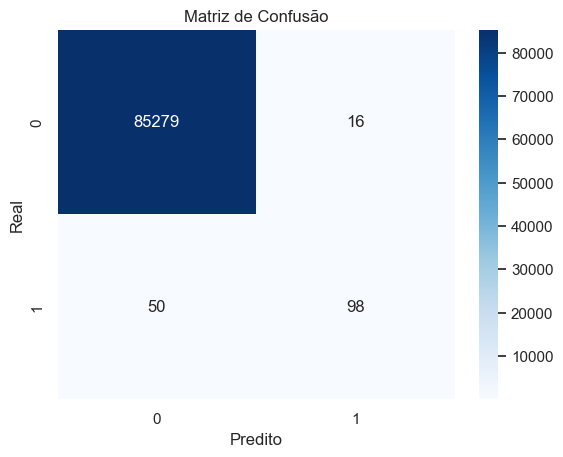

In [38]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

8. Relatório de classificação

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.66      0.75       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Observa-se que o modelo apresentou 50 falsos negativos, o que representa uma parcela significativa das transações fraudulentas no conjunto de teste. Isso indica que o modelo ainda falha em detectar uma quantidade relevante de fraudes, o que pode resultar em prejuízos financeiros.

9. Treinamento com ajuste para desbalanceamento

In [40]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


10. Nova matriz de confusão

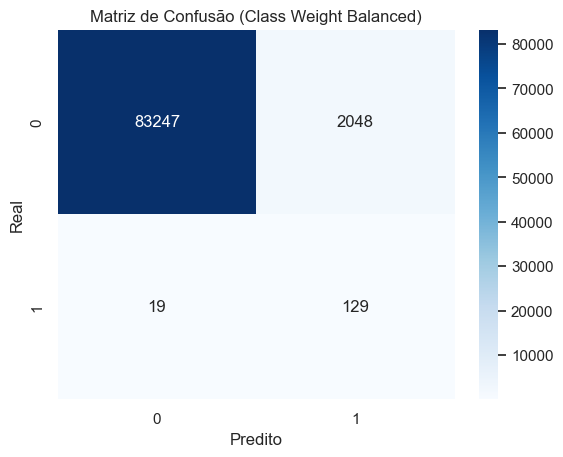

In [41]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Class Weight Balanced)')
plt.show()

11. Novo relatório

In [42]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



Análise do Trade-off entre Falsos Positivos e Falsos Negativos

No contexto de detecção de fraudes financeiras, observa-se um trade-off claro entre falsos positivos e falsos negativos. Ao aplicar o parâmetro class_weight='balanced', o modelo passou a detectar um número maior de fraudes, reduzindo significativamente os falsos negativos (de 50 para 19).

No entanto, essa melhoria ocorreu ao custo de um aumento expressivo nos falsos positivos (de 16 para 2048), ou seja, mais transações legítimas foram classificadas incorretamente como fraude.

Apesar desse aumento, em cenários financeiros reais, é geralmente preferível lidar com um maior número de falsos positivos do que permitir que fraudes passem despercebidas. Isso ocorre porque falsos negativos representam perdas financeiras diretas, possíveis prejuízos aos clientes e danos à reputação da instituição.

Por outro lado, falsos positivos, embora impactem a experiência do usuário ao bloquear transações legítimas, podem ser mitigados por mecanismos adicionais, como autenticação em duas etapas, validações manuais ou notificações ao cliente.

Dessa forma, um modelo mais sensível à detecção de fraudes, mesmo que mais rigoroso, tende a ser mais adequado para aplicações financeiras, priorizando a segurança em detrimento da conveniência.

12. Avaliação de Regularização (L1, L2 e ElasticNet)

Modelo com Regularização L1

In [43]:
model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    C=1
)

model_l1.fit(X_train, y_train)
y_pred_l1 = model_l1.predict(X_test)

Matriz de confusão — L1

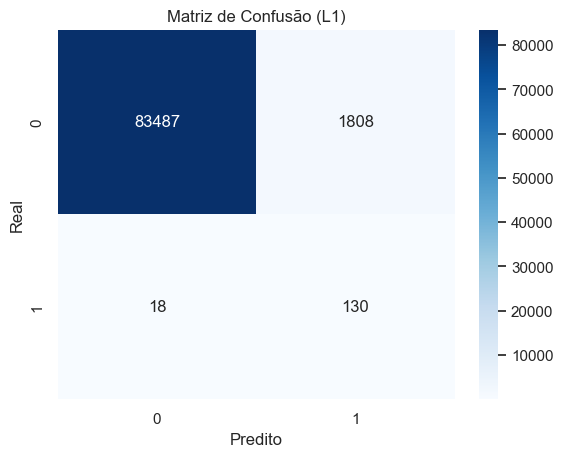

In [44]:
cm_l1 = confusion_matrix(y_test, y_pred_l1)

sns.heatmap(cm_l1, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão (L1)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Relatório — L1

In [45]:
print(classification_report(y_test, y_pred_l1))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



Modelo com Regularização L2 (padrão)

In [46]:
model_l2 = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    class_weight='balanced',
    C=1
)

model_l2.fit(X_train, y_train)
y_pred_l2 = model_l2.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Matriz de confusão — L2

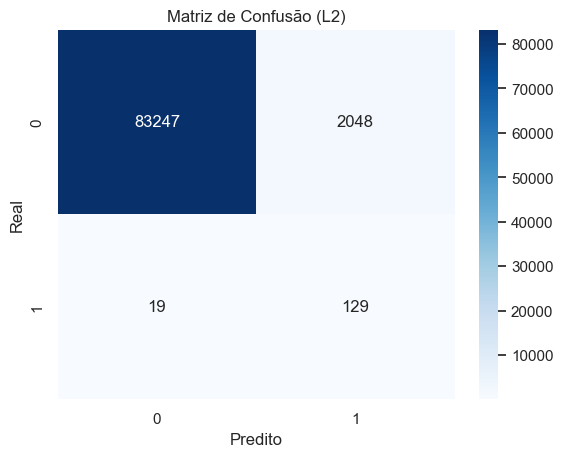

In [47]:
cm_l2 = confusion_matrix(y_test, y_pred_l2)

sns.heatmap(cm_l2, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão (L2)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Relatório — L2

In [48]:
print(classification_report(y_test, y_pred_l2))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



Modelo com ElasticNet

In [49]:
model_en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=1000,
    class_weight='balanced',
    C=1
)

model_en.fit(X_train, y_train)
y_pred_en = model_en.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Matriz de confusão — ElasticNet

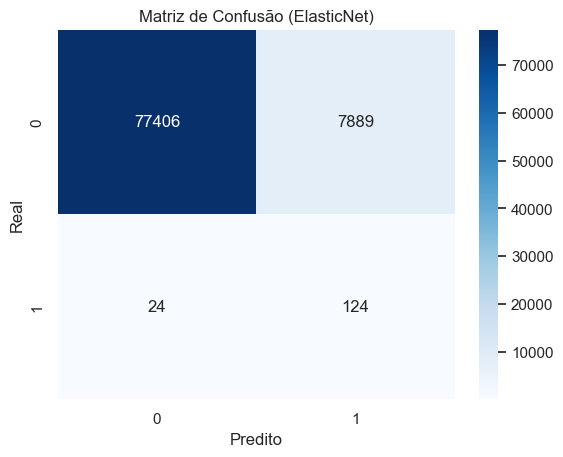

In [50]:
cm_en = confusion_matrix(y_test, y_pred_en)

sns.heatmap(cm_en, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão (ElasticNet)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Relatório — ElasticNet

In [51]:
print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     85295
           1       0.02      0.84      0.03       148

    accuracy                           0.91     85443
   macro avg       0.51      0.87      0.49     85443
weighted avg       1.00      0.91      0.95     85443



13. Avaliação do parâmetro C

Teste com diferentes valores de C

In [52]:
for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(
        C=c,
        max_iter=1000,
        class_weight='balanced'
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f'\n=== C = {c} ===')
    print(confusion_matrix(y_test, y_pred))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== C = 0.01 ===
[[83345  1950]
 [   19   129]]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== C = 0.1 ===
[[83098  2197]
 [   19   129]]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== C = 1 ===
[[83247  2048]
 [   19   129]]

=== C = 10 ===
[[83194  2101]
 [   19   129]]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


14. Análise dos Resultados — Regressão Logística

**Comparação entre Regularizações (L1, L2 e ElasticNet)**

A análise dos diferentes tipos de regularização evidencia impactos relevantes no comportamento do modelo de regressão logística, especialmente no contexto de dados desbalanceados.

O modelo com regularização L1 apresentou o melhor desempenho geral na detecção de fraudes, com menor número de falsos negativos (18), indicando maior capacidade de identificar corretamente transações fraudulentas. Além disso, manteve um número relativamente controlado de falsos positivos (1808), quando comparado com outras abordagens.

O modelo com regularização L2 apresentou desempenho semelhante, porém com ligeiramente mais falsos negativos (19) e maior número de falsos positivos (2048), indicando uma leve piora na eficiência em relação ao L1.

Já o modelo com ElasticNet apresentou desempenho inferior, com aumento tanto nos falsos negativos (24) quanto nos falsos positivos (7889), sugerindo que a combinação das regularizações não foi eficaz neste cenário específico.

**Análise do parâmetro C (força da regularização)**

A variação do parâmetro C não apresentou melhorias significativas no desempenho do modelo. Observou-se que, independentemente do valor de C (0.01, 0.1, 1, 10), o número de falsos negativos permaneceu praticamente constante (em torno de 19), enquanto os falsos positivos variaram levemente.

Isso indica que, para este dataset, o ajuste da regularização não impactou de forma significativa a capacidade do modelo em detectar fraudes, sugerindo que os dados já apresentam uma estrutura bem definida para separação das classes.

Adicionalmente, foram observados avisos de convergência ("TOTAL NO. OF ITERATIONS REACHED LIMIT"), indicando que o modelo pode não ter convergido completamente. Isso sugere que o aumento do parâmetro max_iter ou a aplicação de técnicas de escalonamento poderiam melhorar a estabilidade do treinamento.

**Conclusão**

A análise demonstrou que a regressão logística é sensível ao desbalanceamento dos dados, exigindo ajustes como o uso de class_weight para melhorar a detecção de fraudes. Observou-se que diferentes tipos de regularização impactam o desempenho do modelo, sendo a regularização L1 a que apresentou melhor equilíbrio entre detecção de fraudes e controle de erros. No entanto, todos os modelos evidenciaram o trade-off entre precisão e recall, reforçando a complexidade do problema.